# EDA and Data Prep 
This notebook prepares and does explorative data analysis on two interesting datasets for camera/sonar fusion 3dgs methods

## Datasets
We will focus on two datasets
1. [**UXO datset**](https://github.com/dfki-ric/uxo-dataset2024): Multi-modal synchronized data for optical and acoustic
sensing of UXOs (**U**ne**X**ploded **O**rdnances) underwater.
2. [**Opti-Acoustic Scene Reconstruction in Highly Turbid Underwater
Environments Dataset**](https://github.com/ivanacollg/sonar_camera_reconstruction/tree/ROS2): Synchronized sonar and camera recordings. Organized into four scenario folders corresponding to
the environments tested in the paper: `tank_piers`, `tank_sea_wall`, `marina_pier`, and `marina_sea_wall`.

## Setup
Dependencies (install once, inside the venv):
```bash
pip install -r requirements.txt
```
- `py7zr`: extracts the UXO `.7z` archives from Zenodo
- `gdown`: downloads from Google Drive (opti-acoustic dataset)
- `rosbags`: pure-Python ROS1/ROS2 bag reader, so no ROS install is needed
- `trimesh`, `plotly`, `fast-simplification`: loading, decimating, and interactively viewing the 3D models

In [3]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from tqdm.auto import tqdm

DATA_ROOT = Path("data")          # raw downloads live here (add to .gitignore)
UXO_ROOT = DATA_ROOT / "uxo"
OPTI_ROOT = DATA_ROOT / "opti_acoustic"
OUT_ROOT = Path("prepared")       # processed output for the 3DGS pipelines

for p in (UXO_ROOT, OPTI_ROOT, OUT_ROOT):
    p.mkdir(parents=True, exist_ok=True)

---
# 1. UXO dataset
Hosted on [Zenodo 13778485](https://zenodo.org/records/13778485). Sensors: **ARIS Explorer 3000** imaging sonar + **GoPro Hero 8**, mounted on a gantry crane (gives accurate poses).

| Archive | Size | Contents |
|---|---|---|
| `sample.7z` | 1.7 GB | Excerpt for exploration. **Start here.** |
| `data_export_calibration.7z` | 1 kB | Calibration matrices |
| `data_export_3dmodels.7z` | 26 MB | Textured target models (GT geometry) |
| `data_export_recordings.7z` | 16.7 GB | All recordings (raw ARIS `.pgm`) |
| `data_export_polar.7z` | 16.5 GB | Polar-transformed sonar `.png` |
| `data_processed.7z` | 61.5 GB | Intermediate processing, probably not needed |

Per-recording layout (from the repo's `scripts/view_recording.py`):
```
recordings/<target_type>/<recording>/
    aris_raw/ or aris_polar/   sonar frames
    gopro/                     camera frames, named by frame index
    gantry.csv                 gantry pose, indexed by aris_frame_idx
    aris_frame_meta.csv        per-frame ARIS header
    aris_file_meta.yaml        per-file ARIS header
    notes.txt                  optional
```
Note: labels are for SD frames, so **multiply label coordinates by 3** to match full-HD frames.

In [25]:
import urllib.request

import py7zr

ZENODO = "https://zenodo.org/records/13778485/files/{}?download=1"
UXO_ARCHIVES = [
    "sample.7z",
    "data_export_calibration.7z",
    "data_export_3dmodels.7z",
    # "data_export_recordings.7z",  # 16.7 GB: uncomment once the sample looks useful
    # "data_export_polar.7z",       # 16.5 GB
]

def download(url: str, dst: Path):
    if dst.exists():
        return dst
    print(f"Downloading {url} -> {dst}")
    with tqdm(unit="B", unit_scale=True) as bar:
        def hook(blocks, bsize, total):
            bar.total = total
            bar.update(blocks * bsize - bar.n)
        urllib.request.urlretrieve(url, dst, reporthook=hook)
    return dst

for name in UXO_ARCHIVES:
    archive = download(ZENODO.format(name), UXO_ROOT / name)
    marker = UXO_ROOT / f".{name}.extracted"
    if not marker.exists():
        with py7zr.SevenZipFile(archive) as z:
            z.extractall(UXO_ROOT)
        marker.touch()

In [24]:
# Inspect what was extracted
for p in sorted(UXO_ROOT.rglob("*")):
    if p.is_dir() and len(p.relative_to(UXO_ROOT).parts) <= 4:
        print(p.relative_to(UXO_ROOT), f"({sum(1 for _ in p.iterdir())} entries)")

3d_models (12 entries)
calibration (2 entries)
calibration/camera_parameters (4 entries)
uxo_samples (6 entries)
uxo_samples/.fr-QafhVl (1 entries)
uxo_samples/.fr-QafhVl/data_export (1 entries)
uxo_samples/.fr-QafhVl/data_export/recordings (1 entries)
uxo_samples/2023-09-20_180722 (8 entries)
uxo_samples/2023-09-20_180722/aris_polar (751 entries)
uxo_samples/2023-09-20_180722/aris_raw (751 entries)
uxo_samples/2023-09-20_180722/gopro (751 entries)
uxo_samples/2023-09-20_180722/labels (743 entries)
uxo_samples/2023-09-21_100927 (8 entries)
uxo_samples/2023-09-21_100927/aris_polar (725 entries)
uxo_samples/2023-09-21_100927/aris_raw (725 entries)
uxo_samples/2023-09-21_100927/gopro (725 entries)
uxo_samples/2023-09-21_100927/labels (768 entries)
uxo_samples/2023-09-21_105856 (8 entries)
uxo_samples/2023-09-21_105856/aris_polar (220 entries)
uxo_samples/2023-09-21_105856/aris_raw (220 entries)
uxo_samples/2023-09-21_105856/gopro (220 entries)
uxo_samples/2023-09-21_105856/labels (206 ent

In [11]:
# Find all recording folders (a folder containing gantry.csv)
uxo_recordings = sorted(p.parent for p in UXO_ROOT.rglob("gantry.csv"))
print(f"{len(uxo_recordings)} recordings")
uxo_recordings[:10]

5 recordings


[PosixPath('data/uxo/uxo_samples/2023-09-20_180722'),
 PosixPath('data/uxo/uxo_samples/2023-09-21_100927'),
 PosixPath('data/uxo/uxo_samples/2023-09-21_105856'),
 PosixPath('data/uxo/uxo_samples/2023-09-21_123500'),
 PosixPath('data/uxo/uxo_samples/2023-09-21_124735')]

In [21]:
def load_uxo_recording(rec: Path, polar: bool = True) -> dict:
    """Sonar frames, GoPro frames, and gantry rows are all keyed by the ARIS frame index."""
    sonar_dir = rec / "aris_polar" if polar and (rec / "aris_polar").is_dir() else rec / "aris_raw"
    notes = rec / "notes.txt"
    return {
        "name": rec.name,
        "target": rec.parent.name,
        "sonar_frames": {int(f.stem): f for f in sorted(sonar_dir.iterdir())},
        "gopro_frames": {int(f.stem): f for f in sorted((rec / "gopro").iterdir())},
        "gantry": pd.read_csv(rec / "gantry.csv", index_col="aris_frame_idx"),
        "frame_meta": pd.read_csv(rec / "aris_frame_meta.csv"),
        "file_meta": yaml.safe_load(open(rec / "aris_file_meta.yaml")),
        "notes": notes.read_text() if notes.exists() else "",
    }

rec = load_uxo_recording(uxo_recordings[0])
print(rec["target"], rec["name"])
print(f"sonar frames: {len(rec['sonar_frames'])}, gopro frames: {len(rec['gopro_frames'])}")
rec["gantry"].head()

uxo_samples 2023-09-20_180722
sonar frames: 751, gopro frames: 751


,x,y,z
aris_frame_idx,,,
139,0.165024,0.999277,-0.25
140,0.165068,0.998217,-0.25
141,0.165123,0.996924,-0.25
142,0.165206,0.995136,-0.25
143,0.165300,0.993138,-0.25


In [22]:
# Which ARIS header fields are available? (range, beam count, frequency, ...)
print(rec["frame_meta"].columns.tolist())
rec["file_meta"]

['FrameIndex', 'FrameTime', 'Version', 'Status', 'sonarTimeStamp', 'TS_Day', 'TS_Hour', 'TS_Minute', 'TS_Second', 'TS_Hsecond', 'TransmitMode', 'WindowStart', 'WindowLength', 'Threshold', 'Intensity', 'ReceiverGain', 'DegC1', 'DegC2', 'Humidity', 'Focus', 'Battery', 'UserValue1', 'UserValue2', 'UserValue3', 'UserValue4', 'UserValue5', 'UserValue6', 'UserValue7', 'UserValue8', 'Velocity', 'Depth', 'Altitude', 'Pitch', 'PitchRate', 'Roll', 'RollRate', 'Heading', 'HeadingRate', 'CompassHeading', 'CompassPitch', 'CompassRoll', 'Latitude', 'Longitude', 'SonarPosition', 'ConfigFlags', 'BeamTilt', 'TargetRange', 'TargetBearing', 'TargetPresent', 'FirmwareRevision', 'Flags', 'SourceFrame', 'WaterTemp', 'TimerPeriod', 'SonarX', 'SonarY', 'SonarZ', 'SonarPan', 'SonarTilt', 'SonarRoll', 'PanPNNL', 'TiltPNNL', 'RollPNNL', 'VehicleTime', 'TimeGGK', 'DateGGK', 'QualityGGK', 'NumSatsGGK', 'DOPGGK', 'EHTGGK', 'HeaveTSS', 'YearGPS', 'MonthGPS', 'DayGPS', 'HourGPS', 'MinuteGPS', 'SecondGPS', 'HSecondGPS

{'AuxFlags': 0,
 'EndFrame': 0,
 'FileSize': 93501952,
 'Flags': 1174405120,
 'Flags3D': 0,
 'FrameCount': 927,
 'FrameInterval': 0,
 'FrameRate': 0,
 'HighResolution': 0,
 'LargeLens': 3288109056,
 'NumRawBeams': 128,
 'OptionalHeaderSize': 0,
 'OptionalTailSize': 0,
 'PulseLength': 0,
 'RadioSeconds': 0,
 'ReceiverGain': 0,
 'RecordInterval': 0,
 'Reverse': 0,
 'SN': 2146,
 'Salinity': 0,
 'SampleRate': 0.0,
 'SamplesPerChannel': 780,
 'SoftwareVersion': 2295,
 'Sspd': 0,
 'StartFrame': 0,
 'ThumbnailFI': 0,
 'TimeLapse': 0,
 'TxMode': 0,
 'UserID1': 0,
 'UserID2': 0,
 'UserID3': 0,
 'UserID4': 0,
 'Version': 88491076,
 'VersionFGPA': 0,
 'VersionMinor': 0,
 'VersionPSuC': 0,
 'WaterTemp': 0,
 'WindowLength': 0.0,
 'WindowStart': 0.0,
 'strDate': b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00',
 'strHeaderID': b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x

### UXO: EDA
TODO:
- [ ] Recordings per target type, frames per recording
- [x] Camera/sonar sync: GoPro frames, sonar frames, and `gantry.csv` rows share the ARIS frame index (e.g. `gopro/0139.jpg` ↔ `aris_polar/0139.png` ↔ gantry row 139)
- [ ] Gantry trajectory coverage: are the viewpoints diverse enough for 3DGS?
- [ ] Sonar range/resolution settings across recordings
- [ ] Camera intrinsics and camera-to-sonar extrinsics from `data_export_calibration`

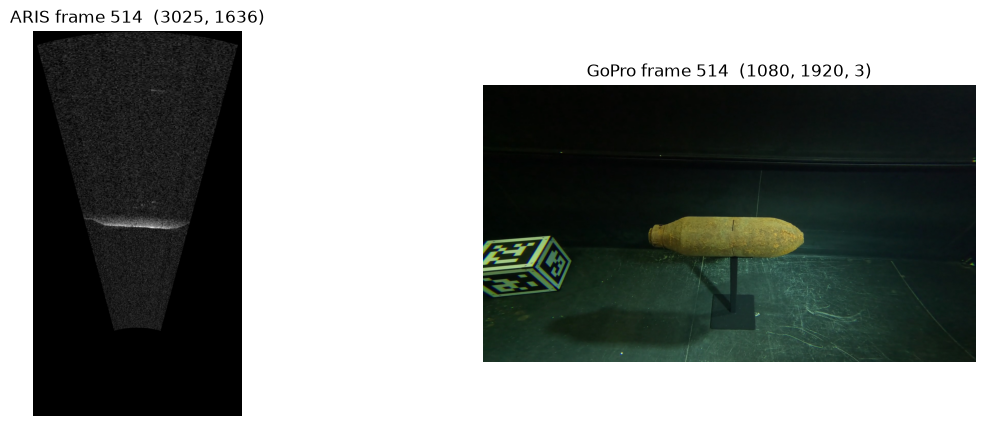

In [23]:
# Side-by-side sonar and camera frame for the same ARIS frame index
synced = sorted(rec["sonar_frames"].keys() & rec["gopro_frames"].keys())
idx = synced[len(synced) // 2]
sonar = cv2.imread(str(rec["sonar_frames"][idx]), cv2.IMREAD_UNCHANGED)
cam = cv2.cvtColor(cv2.imread(str(rec["gopro_frames"][idx])), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(sonar, cmap="gray"); ax[0].set_title(f"ARIS frame {idx}  {sonar.shape}")
ax[1].imshow(cam); ax[1].set_title(f"GoPro frame {idx}  {cam.shape}")
for a in ax: a.axis("off")

['x', 'y', 'z']


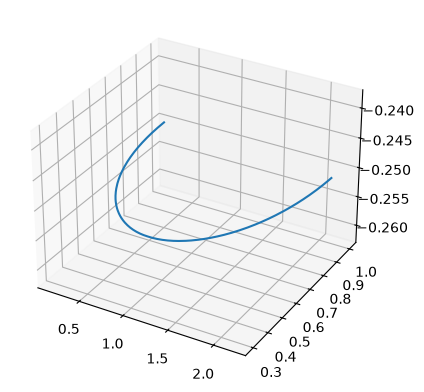

In [18]:
# Gantry trajectory. Print the columns first, then adjust the x/y/z names
g = rec["gantry"]
print(g.columns.tolist())
fig = plt.figure(); ax = fig.add_subplot(projection="3d")
ax.plot(g["x"], g["y"], g["z"])

### UXO: 3D target models
Textured photogrammetry meshes (Agisoft Metashape) of the targets, meant as ground-truth geometry.
- The meshes are **not metric**: they are in arbitrary Metashape units with an arbitrary offset (the 100 lbs bomb spans ~4.8 units). They have to be scaled and aligned to the target poses in `calibration/transforms.yaml` before they can be used for evaluation.
- Two `.mtl` files (`incindiary`, `mortar_shell`) reference textures by old names that aren't in the archive, so the loader always reads the `.jpg` next to the `.obj` instead.
- The full meshes are 65k to 190k faces, so they are decimated for display to keep the notebook responsive. Colours are carried over from the nearest original vertex.

In [16]:
import plotly.graph_objects as go
import trimesh
from PIL import Image
from plotly.subplots import make_subplots
from scipy.spatial import cKDTree

UXO_MODELS = UXO_ROOT / "3d_models"

def load_uxo_model(path: Path, max_faces: int | None = 40_000):
    """Return (vertices, faces, per-vertex RGB) for a textured OBJ, optionally decimated."""
    mesh = trimesh.load(path, process=False)
    mesh.visual.material.image = Image.open(path.with_suffix(".jpg"))
    colors = mesh.visual.to_color().vertex_colors[:, :3]
    verts, faces = np.asarray(mesh.vertices), np.asarray(mesh.faces)
    if max_faces is not None and len(faces) > max_faces:
        small = mesh.simplify_quadric_decimation(face_count=max_faces)
        _, nearest = cKDTree(verts).query(small.vertices)
        verts, faces, colors = np.asarray(small.vertices), np.asarray(small.faces), colors[nearest]
    return verts, faces, colors

def mesh_trace(verts, faces, colors) -> go.Mesh3d:
    return go.Mesh3d(
        x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        vertexcolor=[f"rgb({r},{g},{b})" for r, g, b in colors],
        lighting=dict(ambient=0.8, diffuse=0.4), hoverinfo="skip",
    )

model_paths = sorted(UXO_MODELS.glob("*.obj"))
for p in model_paths:
    v, _, _ = load_uxo_model(p, max_faces=None)
    print(f"{p.stem:16s} {len(v):7d} verts  extent (model units) {np.ptp(v, axis=0).round(2)}")

100lbs            102467 verts  extent (model units) [4.81 1.33 1.49]
artillery_shell    33220 verts  extent (model units) [0.51 1.56 0.94]
incindiary         91448 verts  extent (model units) [5.36 1.61 1.75]
mortar_shell       68123 verts  extent (model units) [9.31 2.81 2.98]


In [17]:
# Interactive viewer: drag to rotate, scroll to zoom. Each model is centred on its own scene.
fig = make_subplots(rows=2, cols=2, specs=[[{"type": "scene"}] * 2] * 2,
                    subplot_titles=[p.stem for p in model_paths], horizontal_spacing=0.02, vertical_spacing=0.05)
for n, p in enumerate(model_paths):
    v, f, c = load_uxo_model(p)
    fig.add_trace(mesh_trace(v - v.mean(axis=0), f, c), row=n // 2 + 1, col=n % 2 + 1)
fig.update_scenes(aspectmode="data", xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
fig.update_layout(height=900, margin=dict(l=0, r=0, t=30, b=0))
fig.show()

---
# 2. Opti-acoustic turbid-water dataset
Data is on [Google Drive](https://drive.google.com/drive/folders/1P7bbY_ikMIOyv38ZTB3Xp3M5JepqIdYG). Sensors: **Oculus M750d** imaging sonar + a monocular camera.

- Scenarios: `tank_piers`, `tank_sea_wall`, `marina_pier`, `marina_sea_wall`
- Tank scenarios have three turbidity levels (`5C`, `7C`, `9C`) and **STL ground-truth models**
- Each scenario has the original ROS1 `.bag` files plus converted ROS2 folders

Topics:
| Topic | Type |
|---|---|
| `/camera/image_raw/compressed` | `sensor_msgs/CompressedImage` |
| `/sonar_oculus_node/M750d/ping` | `sonar_oculus/OculusPing` (custom) |
| `/bruce/slam/localization/odom` | `nav_msgs/Odometry` |

We read the **ROS1 bags** with `rosbags`. ROS1 bags embed their message definitions, so the custom `OculusPing` type can be registered straight from the bag without installing any ROS packages.

Camera intrinsics and sonar parameters are in the repo's launch/config files, which vary by environment (`tank`, `marina_pier`, `marina_seawall`). TODO: copy them into this notebook.

In [ ]:
import gdown

# Downloads the whole folder, which may be large. Consider fetching one scenario first.
if not any(OPTI_ROOT.iterdir()):
    gdown.download_folder(
        "https://drive.google.com/drive/folders/1P7bbY_ikMIOyv38ZTB3Xp3M5JepqIdYG",
        output=str(OPTI_ROOT), quiet=False,
    )

opti_bags = sorted(OPTI_ROOT.rglob("*.bag"))
for b in opti_bags:
    print(f"{b.relative_to(OPTI_ROOT)}  {b.stat().st_size / 1e9:.2f} GB")

TypeError: download_folder() got an unexpected keyword argument 'remaining_ok'

In [ ]:
from rosbags.rosbag1 import Reader
from rosbags.typesys import Stores, get_typestore, get_types_from_msg

def make_typestore(bag_path: Path):
    """Typestore with the standard ROS1 types plus any custom types embedded in the bag."""
    ts = get_typestore(Stores.ROS1_NOETIC)
    with Reader(bag_path) as r:
        for c in r.connections:
            if c.msgtype not in ts.types:
                ts.register(get_types_from_msg(c.msgdef.data, c.msgtype))
    return ts

bag = opti_bags[0]
typestore = make_typestore(bag)
with Reader(bag) as r:
    print(f"{bag.name}: {r.duration / 1e9:.1f} s, {r.message_count} msgs")
    for c in r.connections:
        print(f"  {c.topic:45s} {c.msgtype:35s} {c.msgcount}")

In [ ]:
# Print the OculusPing definition to see which fields hold the sonar image, range, and bearings
with Reader(bag) as r:
    ping_conn = next(c for c in r.connections if "ping" in c.topic)
    print(ping_conn.msgdef.data)

In [ ]:
CAM_TOPIC = "/camera/image_raw/compressed"
SONAR_TOPIC = "/sonar_oculus_node/M750d/ping"
ODOM_TOPIC = "/bruce/slam/localization/odom"

def read_topic(bag_path: Path, topic: str, limit: int | None = None):
    """Yield (timestamp_ns, deserialized msg)."""
    with Reader(bag_path) as r:
        conns = [c for c in r.connections if c.topic == topic]
        for n, (conn, t, raw) in enumerate(r.messages(connections=conns)):
            if limit is not None and n >= limit:
                break
            yield t, typestore.deserialize_ros1(raw, conn.msgtype)

# Odometry -> DataFrame
odom = pd.DataFrame([
    dict(t=t * 1e-9,
         x=m.pose.pose.position.x, y=m.pose.pose.position.y, z=m.pose.pose.position.z,
         qx=m.pose.pose.orientation.x, qy=m.pose.pose.orientation.y,
         qz=m.pose.pose.orientation.z, qw=m.pose.pose.orientation.w)
    for t, m in read_topic(bag, ODOM_TOPIC)
])
odom.describe()

In [ ]:
# First camera frame
t_cam, img_msg = next(read_topic(bag, CAM_TOPIC))
cam = cv2.cvtColor(cv2.imdecode(np.frombuffer(img_msg.data, np.uint8), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

# First sonar ping. Field names depend on the definition printed above
t_son, ping = next(read_topic(bag, SONAR_TOPIC))
print([f for f in dir(ping) if not f.startswith("_")])
# TODO: decode the ping image (likely a nested CompressedImage), then plot it next to `cam`

plt.imshow(cam); plt.title(f"camera t={t_cam*1e-9:.2f}"); plt.axis("off");

### Opti-acoustic: EDA
TODO:
- [ ] Message rates per topic, and camera/sonar time offsets (nearest-neighbour sync)
- [ ] Odometry trajectory per scenario (top-down plot)
- [ ] Image quality vs. turbidity (5C/7C/9C), e.g. contrast/sharpness statistics
- [ ] Sonar settings: range, number of beams, bearing span
- [ ] Register the STL ground truth to the odometry frame for evaluation

---
# 3. Export to a common format
Goal: one layout both datasets export into, which the camera/sonar 3DGS methods can read. Proposed layout (to be decided):
```
prepared/<dataset>/<sequence>/
    images/000000.png
    sonar/000000.npy              polar intensity (range x beam)
    transforms.json               nerfstudio-style: intrinsics + per-frame camera c2w
    sonar_poses.json              per-frame sonar pose + range/fov params
    gt_mesh.(ply|stl)             if available
```
Open questions:
- Which 3DGS codebase(s) is this for, and what input format do they expect?
- Keep sonar in polar form (native), or convert to Cartesian?
- Coordinate conventions: OpenCV vs. OpenGL camera frame, units in metres

In [ ]:
# TODO: export functions per dataset